In [4]:
from google.colab import files
files.upload()

Saving archive.zip to archive.zip


{'archive.zip': b'PK\x03\x04-\x00\x00\x00\x08\x005eeQ\t\xe7\xae\x04\xff\xff\xff\xff\xff\xff\xff\xff\x19\x00\x14\x00Unemployment in India.csv\x01\x00\x10\x00\xc3\xb7\x00\x00\x00\x00\x00\x00x,\x00\x00\x00\x00\x00\x00\xbd}\xcb\x8e`\xb9\x91\xdd\xde\x80\xff!76l\xa0\x95\xe0+\xf8X\xce\xcb#\x8cflA\x96\xe0uJ]P\x95\xd4]-gU/\xfa\xdbf1\x9f\xe4_pD\x90A\xc6\xbd\x0c\xde\xd6b0\xdd\x8bDe\x15\xc9`0\xde\x0c\x9e\xfb\xff\xfe\xf5\xdf~\xf3\xe1\x8f\x9f~\xf8\xfc\xcd\xcb\xdf\xbf}\xfd\xf0\xcd\xcb\xffx\xff\xf0\x7f\x7f\xfc\xf0\xf9\x0f?}\xf3\xf2\x0f_\xbe~\xfa\x1e\x7f\xf9\xed\xcb\xef>\x7f\xf8\xfe/\xdf\xfd\xf0\xd3\xf7\x1f>\x7f}\xf9\r\xfe\xea\xe5\xbf\xfd\x97\xff\xae\xff\xc1?\xf0_\x7f\xf8V\xff\xee\x9f\xdf~\xff\xc3\x8f\xef/\xbf~{\xff\xfa\xe9\x0f\x9f\xfe\xf2\xf6\x15WY\x83\xff\xe6\xfd\xc3\xdb\x7f\xfeO\x7f\xf3\xf9\xdb\x8f\xefo/\xbf~\x7f\xfb\xf6\xc3\x97\x8f\xdf\xbcD\xff\x0b\x07\xbf\x08\xce\xb7o^\xfe\xe5\x87\xcf_?~\x87t\xc4\xd7\x0c\xdf\xbcx\xdfZ\xf3\xb1\xbd:\xf7\xcdK\x8a\xaf!}\xf3\x9b\x1f\xdf\xdf\xbe3&q\xbfpy\x9f\xc4\xf1$\x0

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [8]:
import zipfile
with zipfile.ZipFile('archive.zip') as z:
  with z.open('Unemployment in India.csv') as f:
    df=pd.read_csv(f)
df


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.isnull().sum()


,0
State,28
Date,28
Frequency,28
Unemployment_Rate,28
Employed,28
Labour_Participation_Rate,28
Area,28


In [14]:
df.columns = ['State', 'Date', 'Frequency', 'Unemployment_Rate',
              'Employed', 'Labour_Participation_Rate', 'Area']
df['State'] = df['State'].str.strip()
df['Area']  = df['Area'].str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(how='all')
print(df.isnull().sum())

State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64


In [16]:
df.shape
print(df['State'].nunique())
print(df['State'].unique())

28
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [17]:
print(df['Date'].min())
print(df['Date'].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


In [34]:
rural_pre  = pre_cov[pre_cov['Area'] == 'Rural']['Unemployment_Rate'].mean()
rural_post = post_cov[post_cov['Area'] == 'Rural']['Unemployment_Rate'].mean()

urban_pre  = pre_cov[pre_cov['Area'] == 'Urban']['Unemployment_Rate'].mean()
urban_post = post_cov[post_cov['Area'] == 'Urban']['Unemployment_Rate'].mean()

print("Rural - Pre:", round(rural_pre, 2), " Post:", round(rural_post, 2))
print("Urban - Pre:", round(urban_pre, 2), " Post:", round(urban_post, 2))

Rural - Pre: 8.09  Post: 16.18
Urban - Pre: 10.84  Post: 19.28


In [36]:
# Average unemployment by state (combining Rural + Urban)
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)
print(state_avg.head(27))

# Worst single-month spike per state
peak = df.loc[df.groupby('State')['Unemployment_Rate'].idxmax()]
print(peak[['State', 'Date', 'Area', 'Unemployment_Rate']].sort_values('Unemployment_Rate', ascending=False).head(10))

State
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Name: Unemployment_Rate, dtype: float64
                State       Date   Area  Unemployment_Rate
627        Puducherry 2020-04-30  Urban              76.74
531         Jharkhand 2020

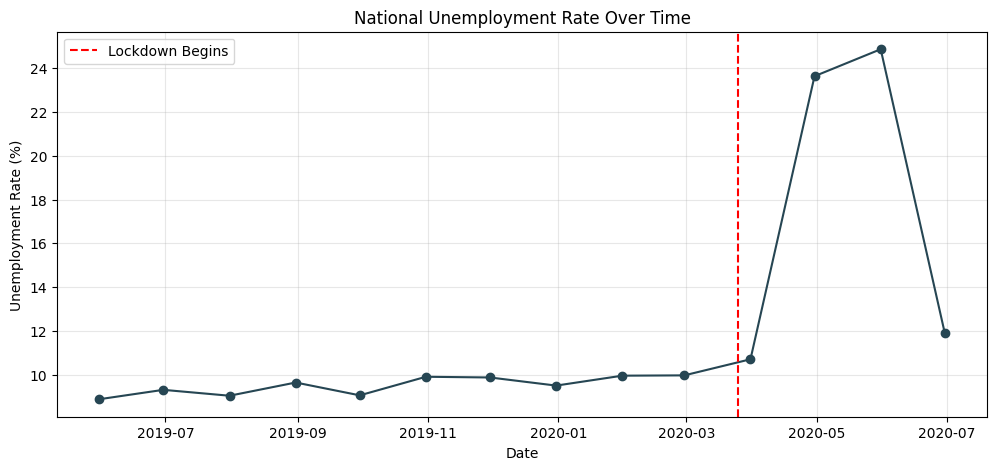

In [37]:
# National monthly average (combining Rural + Urban)
national = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(national['Date'], national['Unemployment_Rate'], marker='o', color='#264653')
plt.axvline(pd.Timestamp('2020-03-25'), color='red', linestyle='--', label='Lockdown Begins')
plt.title('National Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

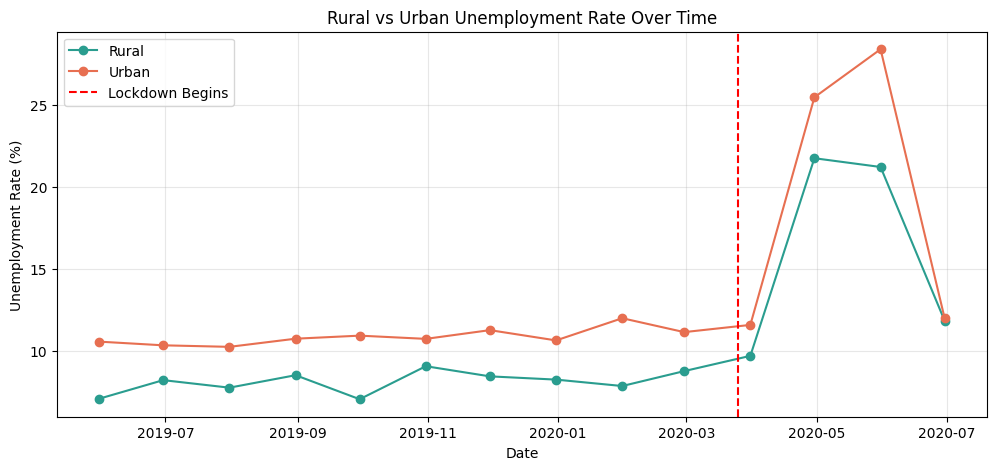

In [38]:
# Group by Date AND Area, then average
area_trend = df.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

# Separate into two lines
rural_trend = area_trend[area_trend['Area'] == 'Rural']
urban_trend = area_trend[area_trend['Area'] == 'Urban']

plt.figure(figsize=(12, 5))
plt.plot(rural_trend['Date'], rural_trend['Unemployment_Rate'], marker='o', label='Rural', color='#2a9d8f')
plt.plot(urban_trend['Date'], urban_trend['Unemployment_Rate'], marker='o', label='Urban', color='#e76f51')
plt.axvline(pd.Timestamp('2020-03-25'), color='red', linestyle='--', label='Lockdown Begins')
plt.title('Rural vs Urban Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

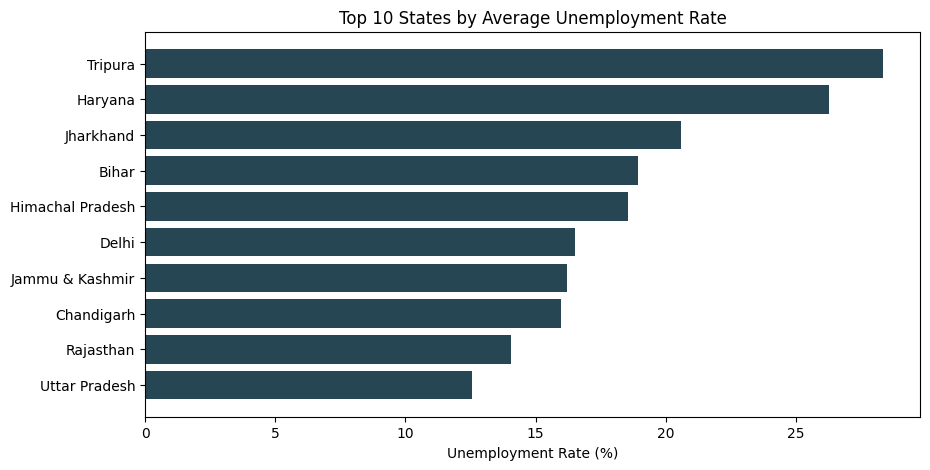

In [39]:
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(state_avg.index, state_avg.values, color='#264653')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.gca().invert_yaxis()
plt.show()

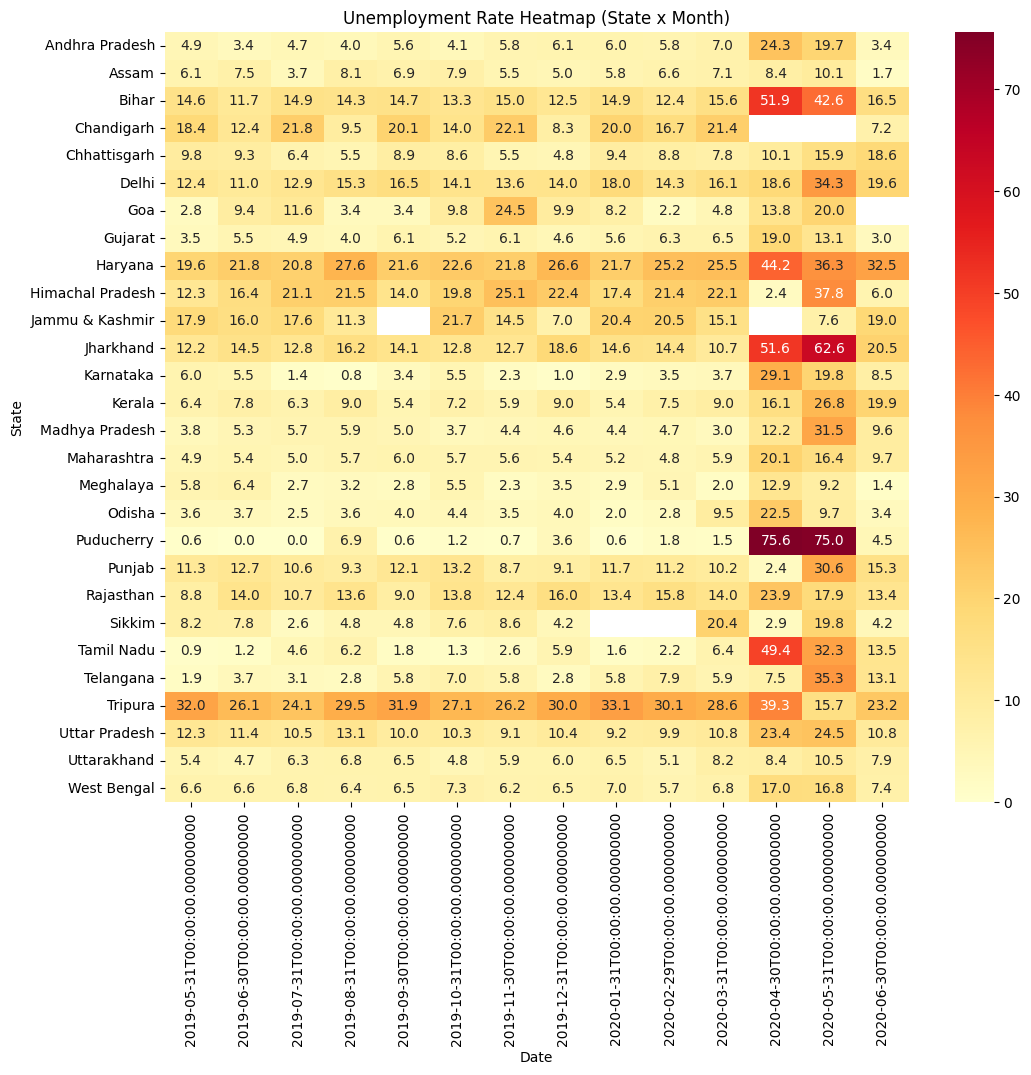

In [41]:
pivot = df.pivot_table(index='State', columns='Date', values='Unemployment_Rate', aggfunc='mean')
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f')
plt.title('Unemployment Rate Heatmap (State x Month)')
plt.show()

In [43]:
print("Avg Unemployment Pre-COVID:", round(avg_pre, 2))
print("Avg Unemployment Post-COVID:", round(avg_post, 2))
print("Rural Pre vs Post:", round(rural_pre,2), "->", round(rural_post,2))
print("Urban Pre vs Post:", round(urban_pre,2), "->", round(urban_post,2))
print("Worst states:\n", state_avg)

Avg Unemployment Pre-COVID: 9.51
Avg Unemployment Post-COVID: 17.77
Rural Pre vs Post: 8.09 -> 16.18
Urban Pre vs Post: 10.84 -> 19.28
Worst states:
 State
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64
